## 📝 Task Brief - Telco Customer Retention
- Project: Telco Churn Risk Analytics
- Role: Junior Data Scientist
- Stakeholder: Customer Retention /  Marketing Team

1. Business Context

Perusahaan telekomunikasi mengalami peningkatan jumlah customer yang berhenti menggunakan layanan (customer churn). Tim Marketing ingin memahami karakteristik customer yang melakukan churn serta mengidentifikasi customer yang memiliki kemungkinan tinggi untuk churn. Saat ini tim belum memiliki sistem berbasis data yang dapat membantu mereka menentukan customer mana yang perlu diprioritaskan untuk program retention.

2. Task

Lakukan analysis mendalam pada data yang diberkan dan membangun model machine learning yang dapat membantu:

a. Memahami karakteristik customer yang melakukan churn.

b. Mengidentifikasi faktor yang berkaitan dengan customer churn.

c. Memprediksi kemungkinan customer melakukan churn.

d. Memberikan insight yang dapat digunakan tim Marketing untuk menyusun strategi retention.

3. Dataset

Dataset customer telekomunikasi memeiliki sekitar 100k records. Target prediction ada pada kolom "Churn"

### 🤔Understanding Dataset

In [216]:
# Necessary Independencies
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# PLt style
plt.style.use("ggplot")

In [217]:
# Raw dataset
telco_df = pd.read_csv(r"D:\Python Course\Telco Churn Risk Analytics\data\raw\synthetic_customer_churn_100k.csv")
dataCols = telco_df.columns
dataShapes = telco_df.shape
dataDesc = telco_df.describe
dataDtype = telco_df.dtypes

print(f"Data columns: {dataCols}\n")
print(f"Data shapes: {dataCols}\n")
print(f"Data types: {dataDtype}\n")

Data columns: Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

Data shapes: Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

Data types: CustomerID          int64
Age                 int64
Gender             object
Tenure              int64
MonthlyCharges    float64
Contract           object
PaymentMethod      object
TotalCharges      float64
Churn              object
dtype: object



In [218]:
telco_df.head(10)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No
5,6,25,Female,29,111.55,Month-to-month,Credit card,3167.13,Yes
6,7,78,Female,20,63.23,One year,Electronic check,1307.22,No
7,8,38,Male,11,96.63,Month-to-month,Bank transfer,1093.32,Yes
8,9,56,Male,43,74.06,Month-to-month,Mailed check,3230.58,Yes
9,10,75,Other,62,109.39,One year,Electronic check,6799.64,No


### 🔍Possible Analysis

In [219]:
telco_df["Contract"].value_counts(), 
churnContract = telco_df[telco_df["Churn"]=="Yes"].groupby("Contract")["Churn"].value_counts()

Persentasi M2M Yes Churn: 0.47
Persentasi 1Y Yes Churn: 0.17
Persentasi 2Y Yes Churn: 0.17


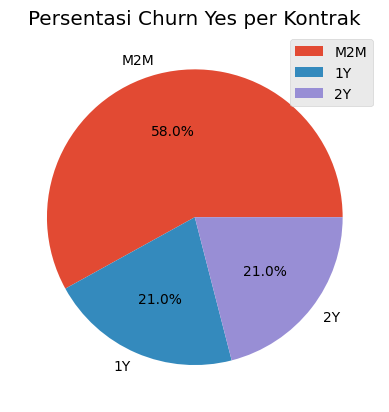

In [220]:
print(f"Persentasi M2M Yes Churn: {np.round(25567/54915,2)}")
print(f"Persentasi 1Y Yes Churn: {np.round(4231/25261,2)}")
print(f"Persentasi 2Y Yes Churn: {np.round(3346/19824,2)}")

plt.title("Persentasi Churn Yes per Kontrak")
plt.pie(x=[np.round(25567/54915,2),np.round(4231/25261,2),np.round(3346/19824,2)],labels=["M2M", "1Y", "2Y"], autopct='%1.1f%%')
plt.legend()

##### Kemungkinan hubungan antar kolom:

Tenure <-> TotalCharges: kedua kolom ini bersangkutan, semakin lama tenurenya maka total charges semakin banyak.

##### Kemungkinan:

Dari data diatas, menurut saya kemungkinan potensi churn pada customer bisa jadi dikarenakan usia(age) dan jenis kontrak(contract), MonthlyCharges, namun kemungkinan yang kuat merujuk pada jenis kontrak. Rata" customer yang melakukan churn ada pada jenis kontrak M2M, namun ini masih menjadi kemungkinan pertama.

In [221]:
telco_df[telco_df["Churn"]=="Yes"].describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,33144.000000,33144.000000,33144.000000,33144.000000,33144.000000
mean,49814.403029,48.875573,30.889784,94.355298,3007.069627
std,28730.565364,18.152871,22.258649,40.295908,2672.518887
min,4.000000,18.000000,1.000000,10.000000,-106.800000
25%,25081.500000,33.000000,9.000000,61.520000,691.780000
50%,49472.000000,49.000000,28.000000,105.840000,2168.510000
75%,74588.500000,65.000000,51.000000,127.812500,4939.192500
max,99998.000000,80.000000,72.000000,150.000000,10831.460000


In [222]:
churnMonthly = telco_df[telco_df["Churn"]=="Yes"].groupby("Churn")["MonthlyCharges"].mean()
churnMonthly

Churn
Yes    94.355298
Name: MonthlyCharges, dtype: float64

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '(Month-to-month, 96.87)'),
  Text(1, 0, '(Month-to-month, 109.93)'),
  Text(2, 0, '(One year, 96.87)'),
  Text(3, 0, '(One year, 109.93)'),
  Text(4, 0, '(Two year, 96.87)'),
  Text(5, 0, '(Two year, 109.93)')])

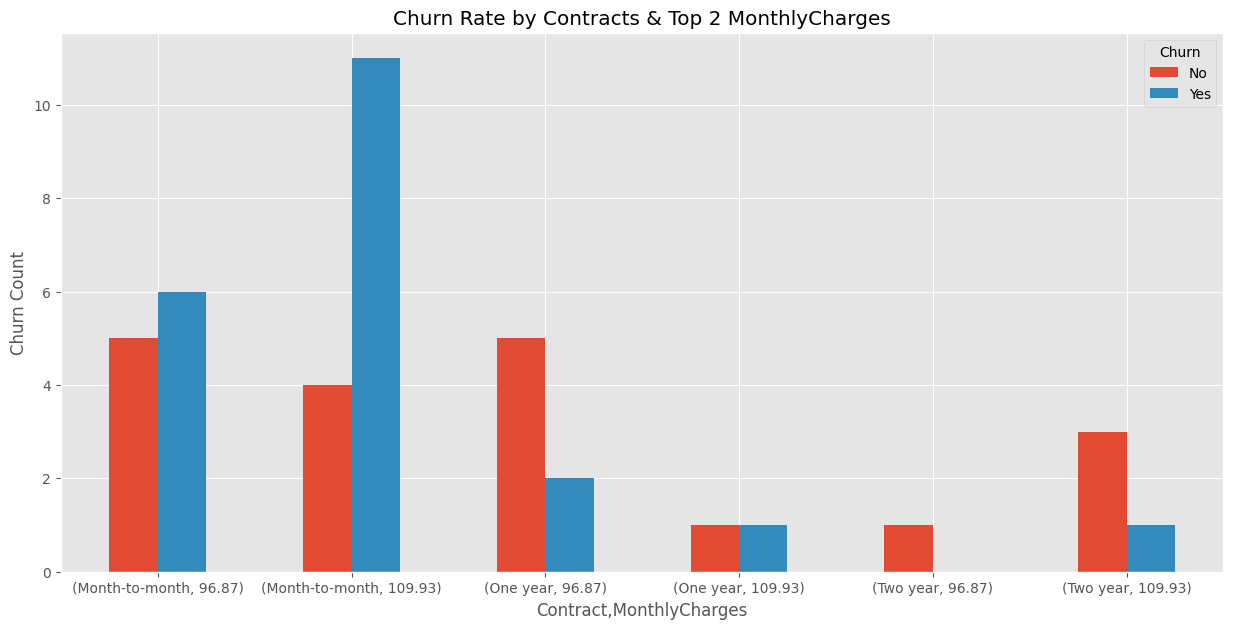

In [223]:
top_monthly = telco_df["MonthlyCharges"].value_counts().head(2).index
churnContractMonthly2 = telco_df.groupby(["Contract","Churn"])["MonthlyCharges"].median().unstack()

churnContractMonthly3 = telco_df[telco_df["MonthlyCharges"].isin(top_monthly)].groupby(["Contract", "MonthlyCharges"])["Churn"].value_counts().unstack(fill_value=0)
churnContractMonthly3.plot(kind="bar",
                           figsize=(15,7),
                           title="Churn Rate by Contracts & Top 2 MonthlyCharges", 
                           ylabel="Churn Count")
plt.xticks(rotation=0)

#### Hasil analisis 1

Dari visual diatas saya mengambil data dari 2 jenis nilai yang sering muncul pada monthlyCharges, yaitu ada di harga 96 dan 109. Harga tersebut bukanlah harga tertinggi melainkan harga yang sering muncul pada data, hal ini bisa memungkinkan mematahkan kalau monthlyCharges memengaruhi churn pada customer. 

In [224]:
telco_df["MonthlyChargesGroup"] = pd.qcut(
    telco_df["MonthlyCharges"],
    q=3,
    labels=["low","medium","high"]
)

Churn,No,Yes
MonthlyChargesGroup,,
low,64.09,35.91
medium,62.15,37.85
high,34.11,65.89


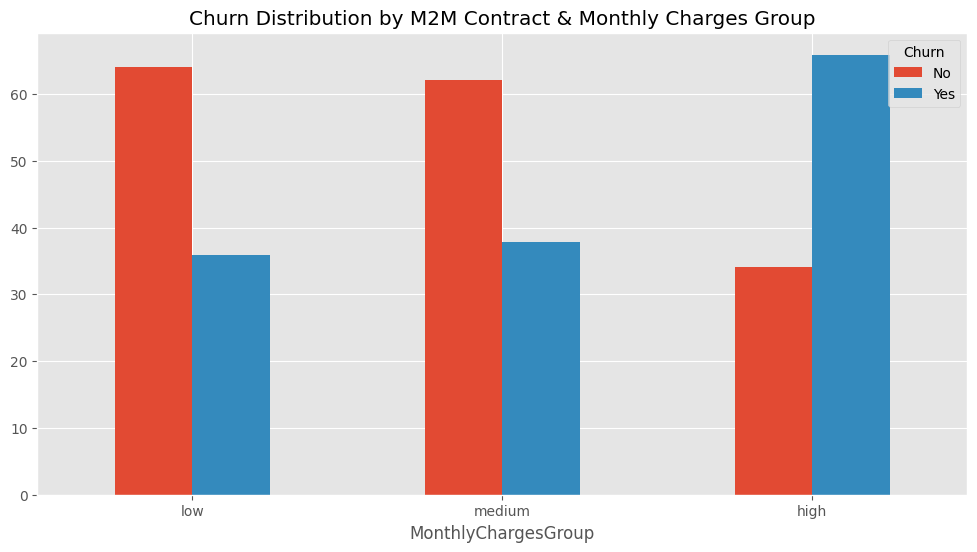

In [265]:
m2m = telco_df[telco_df["Contract"]=="Month-to-month"]
churnContractMonthly4 = np.round(pd.crosstab(
                                    m2m["MonthlyChargesGroup"],
                                    m2m["Churn"],
                                    normalize="index"
                                )*100, 2)

churnContractMonthly4.plot(kind="bar", figsize=(12, 6), title="Churn Distribution by M2M Contract & Monthly Charges Group")
plt.xticks(rotation=0)
churnContractMonthly4

#### Hasil analisis 2

Dari visual diatas saya membuat group untuk membagi tipe monthlyCharges yaitu ada low, medium, high, ini berdasarkan q=3. Lalu disini saya mencari rate churn yang hanya memfokuskan contract Month to Month (M2M). Dari visual data diatas, Churn cenderung tinggi pada jenis monthlyCharges yang tinggi (High).